# Projet Trajectoire — MA266

Ce notebook regroupe l'ensemble des scripts du projet d'analyse de trajectoire balistique.

**Auteurs** : Liam ADGH, Aurélien de Almeida

---

### Sommaire

1. Extraction vidéo (OpenCV)
2. Simulation de trajectoire (sans frottement / traînée linéaire)
3. Problème inverse sans frottement
4. Problème inverse avec traînée linéaire (pénalisation, projection, barrière)
5. Analyse de sensibilité et régularisation de Tikhonov
6. Simulation avec traînée quadratique
7. Comparaison traînée linéaire vs quadratique

---

In [1]:
import os
import sys
import subprocess
import multiprocessing
import cv2

import numpy as np
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

from sensibilite import (
    analyse_sensibilite, calculer_stats,
    tracer_sensibilite, tracer_variance
)

G = 9.81
DEVICE = torch.device('cpu')

# 1. Extraction de la trajectoire depuis une vidéo

Détection du projectile par seuillage HSV et calcul du centroïde avec OpenCV.
Calibration pixel → mètre avec inversion de l'axe y.

> **Note** : Ce script nécessite `opencv-python` et une vidéo en entrée. Il peut être ignoré si l'on travaille directement avec des données simulées.

#### Extraction — extraction_trajectoire.py

In [2]:
"""
Script d'extraction de la trajectoire d'un projectile depuis une video.
Utilise OpenCV pour detecter l'objet par seuillage HSV et calcul du centroide.
Retourne une liste de tuples (t, x, y) en metres avec y oriente vers le haut.
"""


# ---------------------------------------------------------------------------
# Parametres de seuillage HSV -- a ajuster selon la couleur du projectile
# ---------------------------------------------------------------------------
HSV_LOWER = np.array([20, 100, 100])   # borne basse (ex: balle orange/jaune)
HSV_UPPER = np.array([35, 255, 255])   # borne haute

# Taille minimale du contour en pixels pour filtrer le bruit
MIN_CONTOUR_AREA = 50


# ---------------------------------------------------------------------------
# Calibration : conversion pixels -> metres
# ---------------------------------------------------------------------------
def calibrer(longueur_reference_m, longueur_reference_px):
    """
    Calcule le facteur de conversion pixel -> metre.

    Parameters
    ----------
    longueur_reference_m : float
        Longueur connue dans la scene, exprimee en metres.
    longueur_reference_px : float
        Meme longueur mesuree en pixels sur l'image.

    Returns
    -------
    float
        Facteur d'echelle (metres par pixel).
    """
    if longueur_reference_px <= 0:
        raise ValueError("La longueur de reference en pixels doit etre > 0")
    return longueur_reference_m / longueur_reference_px


def pixels_vers_metres(x_px, y_px, echelle, hauteur_image):
    """
    Convertit des coordonnees pixel en coordonnees metriques.
    L'axe y est inverse : l'origine est placee en bas a gauche.

    Parameters
    ----------
    x_px, y_px : float
        Coordonnees en pixels (origine en haut a gauche).
    echelle : float
        Facteur metres/pixel issu de calibrer().
    hauteur_image : int
        Hauteur de l'image en pixels.

    Returns
    -------
    (float, float)
        Coordonnees (x, y) en metres, y oriente vers le haut.
    """
    x_m = x_px * echelle
    y_m = (hauteur_image - y_px) * echelle
    return x_m, y_m


# ---------------------------------------------------------------------------
# Extraction des positions
# ---------------------------------------------------------------------------
def extraire_positions(chemin_video, echelle,
                       hsv_lower=None, hsv_upper=None,
                       afficher=False):
    """
    Parcourt la video image par image, detecte le projectile par seuillage
    HSV et retourne la liste des positions calibrees.

    Parameters
    ----------
    chemin_video : str
        Chemin vers le fichier video.
    echelle : float
        Facteur metres/pixel (resultat de calibrer()).
    hsv_lower : np.ndarray, optional
        Borne basse HSV. Par defaut HSV_LOWER global.
    hsv_upper : np.ndarray, optional
        Borne haute HSV. Par defaut HSV_UPPER global.
    afficher : bool
        Si True, affiche la detection en temps reel (appuyer sur 'q' pour quitter).

    Returns
    -------
    list[tuple[float, float, float]]
        Liste de tuples (t, x, y) ou t est en secondes et x, y en metres.
    """
    if hsv_lower is None:
        hsv_lower = HSV_LOWER
    if hsv_upper is None:
        hsv_upper = HSV_UPPER

    cap = cv2.VideoCapture(chemin_video)
    if not cap.isOpened():
        raise FileNotFoundError(f"Impossible d'ouvrir la video : {chemin_video}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        raise ValueError("Impossible de lire le FPS de la video")

    hauteur_image = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    positions = []
    index_frame = 0

    noyau = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        t = index_frame / fps

        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        masque = cv2.inRange(hsv, hsv_lower, hsv_upper)

        masque = cv2.morphologyEx(masque, cv2.MORPH_OPEN, noyau)
        masque = cv2.morphologyEx(masque, cv2.MORPH_CLOSE, noyau)

        contours, _ = cv2.findContours(masque, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            plus_grand = max(contours, key=cv2.contourArea)
            aire = cv2.contourArea(plus_grand)

            if aire >= MIN_CONTOUR_AREA:
                M = cv2.moments(plus_grand)
                if M["m00"] > 0:
                    cx = M["m10"] / M["m00"]
                    cy = M["m01"] / M["m00"]

                    x_m, y_m = pixels_vers_metres(cx, cy, echelle,
                                                  hauteur_image)
                    positions.append((t, x_m, y_m))

                    if afficher:
                        centre = (int(cx), int(cy))
                        cv2.circle(frame, centre, 6, (0, 255, 0), -1)
                        cv2.putText(frame,
                                    f"({x_m:.3f}, {y_m:.3f}) m",
                                    (centre[0] + 10, centre[1] - 10),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                                    (0, 255, 0), 1)

        if afficher:
            cv2.imshow("Detection", frame)
            cv2.imshow("Masque", masque)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        index_frame += 1

    cap.release()
    if afficher:
        cv2.destroyAllWindows()

    return positions


# ---------------------------------------------------------------------------
# Utilitaire : sauvegarde CSV
# ---------------------------------------------------------------------------
def sauvegarder_csv(positions, chemin_csv):
    """Ecrit les positions dans un fichier CSV (t, x, y)."""
    with open(chemin_csv, 'w') as f:
        f.write("t,x,y\n")
        for t, x, y in positions:
            f.write(f"{t:.6f},{x:.6f},{y:.6f}\n")

#### Exécution — extraction_trajectoire.py

In [3]:
## -- Configuration utilisateur ------------------------------------------
#
#CHEMIN_VIDEO = "video_projectile.mp4"
#
## Calibration : mesurer un objet de reference dans la video
## Exemple : un objet de 1.0 m mesure 320 pixels sur l'image
#LONGUEUR_REF_M = 1.0
#LONGUEUR_REF_PX = 320.0
#
#echelle = calibrer(LONGUEUR_REF_M, LONGUEUR_REF_PX)
#print(f"Echelle de calibration : {echelle:.6f} m/px")
#
## -- Extraction ---------------------------------------------------------
#
#positions = extraire_positions(CHEMIN_VIDEO, echelle, afficher=True)
#
#print(f"\n{len(positions)} positions extraites.")
#for t, x, y in positions[:10]:
#    print(f"  t={t:.4f} s  |  x={x:.4f} m  |  y={y:.4f} m")
#
#if len(positions) > 10:
#    print(f"  ... ({len(positions) - 10} positions supplementaires)")
#
## -- Sauvegarde ---------------------------------------------------------
#
#sauvegarder_csv(positions, "positions_trajectoire.csv")
#print("Resultats sauvegardes dans positions_trajectoire.csv")

# 2. Simulation de trajectoire (sans frottement / traînée linéaire)

Génération de trajectoires théoriques et d'observations bruitées.

- **Sans frottement** : équations analytiques classiques.
- **Avec traînée linéaire** : résolution de l'EDO par RK45 (scipy).
- Ajout de bruit gaussien pour simuler l'imprécision d'une caméra.

#### simulation_trajectoire.py

In [4]:
"""
Simulation d'une trajectoire balistique (sans ou avec frottement).
Génère des données théoriques et des observations bruitées
exploitables par un algorithme d'optimisation.
"""


# ---------------------------------------------------------------------------
# Génère une trajectoire
# ---------------------------------------------------------------------------
def generate_trajectory(v0, theta, t_max, num_points):
    """
    Calcule la trajectoire théorique d'un projectile sans frottement.

    Parameters
    ----------
    v0 : float
        Vitesse initiale en m/s.
    theta : float
        Angle de tir en radians.
    t_max : float
        Durée maximale de la simulation en secondes.
    num_points : int
        Nombre de points temporels.

    Returns
    -------
    t : np.ndarray
        Vecteur temps de taille num_points.
    x : np.ndarray
        Positions horizontales théoriques (m).
    y : np.ndarray
        Positions verticales théoriques (m).
    """
    t = np.linspace(0, t_max, num_points)
    x = v0 * np.cos(theta) * t
    y = v0 * np.sin(theta) * t - 0.5 * G * t**2
    return t, x, y

# ---------------------------------------------------------------------------
# Génère une trajectoire avec trainée linéaire
# ---------------------------------------------------------------------------
def generate_trajectory_drag(v0, theta, gamma, t_max, num_points):
    """
    Calcule la trajectoire avec trainée linéaire (gamma = k/m).
    EDO : dvx/dt = -gamma*vx, dvy/dt = -g - gamma*vy
    Integration par RK45.

    Parameters
    ----------
    v0 : float
        Vitesse initiale (m/s).
    theta : float
        Angle de tir (rad).
    gamma : float
        Coéfficient de trainée k/m (s^-1).
    t_max : float
        Duree maximale (s).
    num_points : int
        Nombre de points temporels.

    Returns
    -------
    t, x, y : np.ndarray
    """
    def edo(t, state):
        _, _, vx, vy = state
        return [vx, vy, -gamma * vx, -G - gamma * vy]

    vx0 = v0 * np.cos(theta)
    vy0 = v0 * np.sin(theta)
    etat0 = [0.0, 0.0, vx0, vy0]

    t_eval = np.linspace(0, t_max, num_points)
    sol = solve_ivp(edo, [0, t_max], etat0, t_eval=t_eval, method='RK45',
                    rtol=1e-10, atol=1e-12)

    return sol.t, sol.y[0], sol.y[1]

# ---------------------------------------------------------------------------
# Ajout du bruit
# ---------------------------------------------------------------------------
def ajouter_bruit(x, y, sigma=0.05):
    """
    Ajoute un bruit blanc gaussien aux coordonnées pour simuler
    l'imprecision d'une camera de smartphone.

    Parameters
    ----------
    x, y : np.ndarray
        Coordonnées theoriques.
    sigma : float
        Ecart-type du bruit en mètres.

    Returns
    -------
    x_obs, y_obs : np.ndarray
        Coordonnées bruitées.
    """
    bruit_x = np.random.normal(0, sigma, size=x.shape)
    bruit_y = np.random.normal(0, sigma, size=y.shape)
    return x + bruit_x, y + bruit_y

# ---------------------------------------------------------------------------
# Graphe de la trajectoire
# ---------------------------------------------------------------------------
def tracer_trajectoire(t, x_th, y_th, x_obs, y_obs, v0, theta_deg):
    """
    Trace la trajectoire théorique et les observations bruitées
    sur un même graphique.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(x_th, y_th, 'b-', linewidth=2, label='Trajectoire théorique')
    ax.scatter(x_obs, y_obs, c='r', s=20, alpha=0.7, zorder=5,
               label='Observations bruitees')

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(f'Trajectoire balistique  |  v0 = {v0} m/s, '
                 f'theta = {theta_deg} deg')
    ax.legend()
    ax.set_ylim(bottom=-0.5)
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('trajectoire_simulee.png', dpi=150)
    plt.show()

#### Exécution — simulation_trajectoire.py

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Mode : AVEC frottement (gamma=0.5)
Parametres : v0=15.0 m/s, theta=45.0 deg, gamma=0.5
Points generes : 72
Bruit (sigma) : 0.08 m

Apercu des donnees (t, x_obs, y_obs) :
  t=0.0000 s  |  x=-0.0389 m  |  y=0.0869 m
  t=0.0262 s  |  x=0.3333 m  |  y=0.2901 m
  t=0.0524 s  |  x=0.4358 m  |  y=0.3561 m
  t=0.0786 s  |  x=0.7796 m  |  y=0.8140 m
  t=0.1048 s  |  x=1.1458 m  |  y=1.0871 m
  t=0.1311 s  |  x=1.2923 m  |  y=1.3879 m
  t=0.1573 s  |  x=1.6222 m  |  y=1.4694 m
  t=0.1835 s  |  x=1.7792 m  |  y=1.7444 m
  ... (64 points supplementaires)
Donnees bruitees sauvegardees dans observations.csv
Trajectoire theorique sauvegardee dans trajectoire_theorique.csv


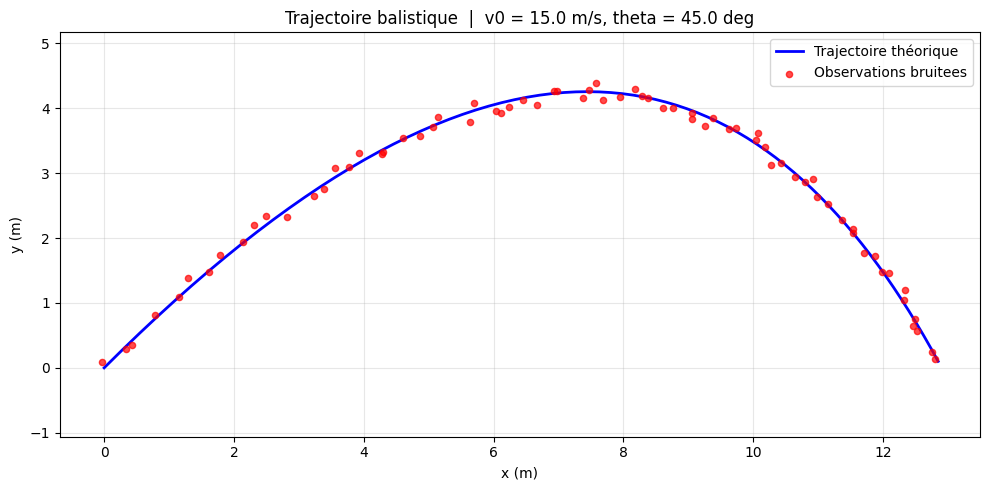

In [5]:
# ---------------------------------------------------------------------------
# Simulation
# ---------------------------------------------------------------------------
# -- Paramètres de simulation -------------------------------------------
v0 = 15.0                   # vitesse initiale (m/s)
theta = np.pi / 4           # angle de tir (rad)
theta_deg = np.degrees(theta)
num_points = 100
sigma_bruit = 0.08          # écart-type du bruit (m)

# Mettre a 0 pour le modèle sans frottement,
# ou a une valeur > 0 pour simuler la traineé (ex: 0.3)
GAMMA = 0.5

# -- Génèration ---------------------------------------------------------
if GAMMA > 0:
    t_vol = 2 * v0 * np.sin(theta) / G  # estimation initiale
    t_max = t_vol * 1.2
    t, x_th, y_th = generate_trajectory_drag(v0, theta, GAMMA,
                                              t_max, num_points)
    print(f"Mode : AVEC frottement (gamma={GAMMA})")
else:
    t_vol = 2 * v0 * np.sin(theta) / G
    t_max = t_vol * 1.05
    t, x_th, y_th = generate_trajectory(v0, theta, t_max, num_points)
    print(f"Mode : SANS frottement")

x_obs, y_obs = ajouter_bruit(x_th, y_th, sigma=sigma_bruit)

# Tronquer les points sous le sol
masque = y_th >= 0
t = t[masque]
x_th = x_th[masque]
y_th = y_th[masque]
x_obs = x_obs[masque]
y_obs = y_obs[masque]

# -- Affichage ----------------------------------------------------------
print(f"Parametres : v0={v0} m/s, theta={theta_deg:.1f} deg"
      f"{f', gamma={GAMMA}' if GAMMA > 0 else ''}")
print(f"Points generes : {len(t)}")
print(f"Bruit (sigma) : {sigma_bruit} m\n")

print("Apercu des donnees (t, x_obs, y_obs) :")
for i in range(min(8, len(t))):
    print(f"  t={t[i]:.4f} s  |  x={x_obs[i]:.4f} m  |  y={y_obs[i]:.4f} m")
if len(t) > 8:
    print(f"  ... ({len(t) - 8} points supplementaires)")

# -- Sauvegarde CSV (même format que extraction_trajectoire.py) ----------
with open("observations.csv", "w") as f:
    f.write("t,x,y\n")
    for i in range(len(t)):
        f.write(f"{t[i]:.6f},{x_obs[i]:.6f},{y_obs[i]:.6f}\n")
print("Donnees bruitees sauvegardees dans observations.csv")

with open("trajectoire_theorique.csv", "w") as f:
    f.write("t,x,y\n")
    for i in range(len(t)):
        f.write(f"{t[i]:.6f},{x_th[i]:.6f},{y_th[i]:.6f}\n")
print("Trajectoire theorique sauvegardee dans trajectoire_theorique.csv")

tracer_trajectoire(t, x_th, y_th, x_obs, y_obs, v0, theta_deg)

# 3. Problème inverse sans frottement

Identification de la vitesse initiale $v_0$ et de l'angle $\theta$ par minimisation des moindres carrés sous contraintes physiques (L-BFGS-B).

$$J(v_0, \theta) = \sum_i \left[(x_i^{obs} - x(t_i))^2 + (y_i^{obs} - y(t_i))^2\right]$$

#### methode_simple.py

In [6]:
"""
Problème inverse : identification de v0 et theta.
Minimise l'écart entre les observations et le modèle balistique sans frottement
en utilisant scipy.optimize.minimize avec contraintes physiques.
"""


# ---------------------------------------------------------------------------
# Modele balistique sans frottement
# ---------------------------------------------------------------------------
def modele_trajectoire(t, v0, theta, x0=0.0, y0=0.0):
    """
    Calcule les positions (x, y) du projectile pour chaque instant t.

    Parameters
    ----------
    t : np.ndarray
        Vecteur temps (s).
    v0 : float
        Vitesse initiale (m/s).
    theta : float
        Angle de tir (rad).
    x0, y0 : float
        Position initiale (m).

    Returns
    -------
    x, y : np.ndarray
    """
    x = x0 + v0 * np.cos(theta) * t
    y = y0 + v0 * np.sin(theta) * t - 0.5 * G * t**2
    return x, y


# ---------------------------------------------------------------------------
# Fonction de cout (somme des residus au carre)
# ---------------------------------------------------------------------------
def fonction_cout(params, t, x_obs, y_obs):
    """
    J(v0, theta, x0, y0) = sum_i [(x_obs_i - x(t_i))^2 + (y_obs_i - y(t_i))^2]
    """
    v0, theta, x0, y0 = params
    x_mod, y_mod = modele_trajectoire(t, v0, theta, x0, y0)
    residus = (x_obs - x_mod)**2 + (y_obs - y_mod)**2
    return np.sum(residus)


# ---------------------------------------------------------------------------
# Optimisation avec contraintes
# ---------------------------------------------------------------------------
def identifier_parametres(t, x_obs, y_obs,
                          v0_init=10.0, theta_init=0.7,
                          x0_init=None, y0_init=None):
    """
    Résout le problème inverse par minimisation sous contraintes.

    Parameters
    ----------
    t, x_obs, y_obs : np.ndarray
        Observations au format standard (t, x, y).
    v0_init, theta_init : float
        Estimations initiales.
    x0_init, y0_init : float, optional
        Estimations initiales de la position de départ.
        Par défaut, prend le premier point observé.

    Returns
    -------
    dict
        Resultats : v0, theta (deg et rad), x0, y0, cout final.
    """
    if x0_init is None:
        x0_init = x_obs[0]
    if y0_init is None:
        y0_init = y_obs[0]

    p0 = [v0_init, theta_init, x0_init, y0_init]

    bornes = [
        (0.1, None),         # v0 > 0
        (0.0, np.pi / 2),    # theta in [0, pi/2]
        (None, None),        # x0 libre
        (None, None),        # y0 libre
    ]

    resultat = minimize(
        fonction_cout, p0,
        args=(t, x_obs, y_obs),
        method='L-BFGS-B',
        bounds=bornes,
        options={'maxiter': 10000, 'ftol': 1e-15}
    )

    v0_opt, theta_opt, x0_opt, y0_opt = resultat.x

    return {
        'v0': v0_opt,
        'theta_rad': theta_opt,
        'theta_deg': np.degrees(theta_opt),
        'x0': x0_opt,
        'y0': y0_opt,
        'cout': resultat.fun,
        'succes': resultat.success,
        'message': resultat.message,
        'resultat_brut': resultat
    }





# ---------------------------------------------------------------------------
# Chargement depuis CSV (format commun t,x,y)
# ---------------------------------------------------------------------------
def charger_csv(chemin):
    """Charge un fichier CSV au format t,x,y."""
    data = np.loadtxt(chemin, delimiter=",", skiprows=1)
    return data[:, 0], data[:, 1], data[:, 2]


# ---------------------------------------------------------------------------
# Visualisation des resultats
# ---------------------------------------------------------------------------
def tracer_resultats(t, x_obs, y_obs, res, params_vrais=None):
    """Trace les observations, le modèle identifie et optionnellement le modèle vrai."""
    x_fit, y_fit = modele_trajectoire(t, res['v0'], res['theta_rad'],
                                       res['x0'], res['y0'])

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.scatter(x_obs, y_obs, c='r', s=20, alpha=0.6, label='Observations bruitees')
    ax.plot(x_fit, y_fit, 'b-', linewidth=2,
            label=f'Modele identifie (v0={res["v0"]:.2f}, '
                  f'theta={res["theta_deg"]:.2f} deg)')

    if params_vrais is not None:
        x_vrai, y_vrai = modele_trajectoire(t, params_vrais['v0'],
                                             params_vrais['theta_rad'])
        ax.plot(x_vrai, y_vrai, 'g--', linewidth=1.5,
                label=f'Verite (v0={params_vrais["v0"]:.2f}, '
                      f'theta={params_vrais["theta_deg"]:.2f} deg)')

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title('Identification des parametres balistiques')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('resultats.png', dpi=150)
    plt.show()

#### Exécution — methode_simple.py

Chargement des observations

--- Resultats de l'optimisation ---
v0    = 11.2211 m/s
theta = 52.4479 deg  (0.915389 rad)
x0    = 1.0203 m
y0    = 0.2210 m
Cout  = 1.559185e+01
Convergence : True (CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL)

--- Comparaison avec les vraies valeurs ---
v0    : vrai=14.9025  estime=11.2211  erreur=3.6815 m/s
theta : vrai=45.0015  estime=52.4479  erreur=7.4464 deg


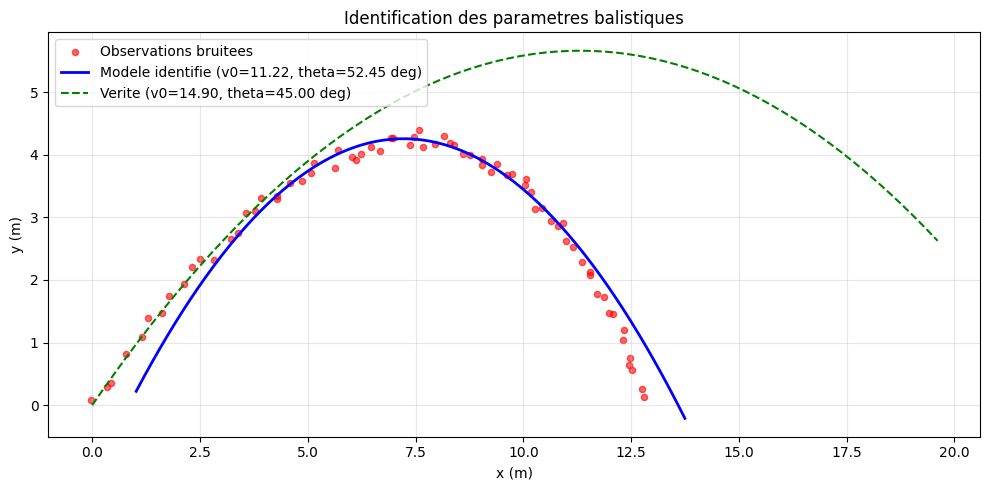

In [7]:
# ---------------------------------------------------------------------------
# Exécution
# ---------------------------------------------------------------------------
# -- Paramètres de simulation -------------------------------------------
CSV_PATH = "observations.csv"
SCRIPT_SIMULATION = "simulation_trajectoire.py"

if not os.path.exists(CSV_PATH):
    print(f"{CSV_PATH} introuvable, lancement de {SCRIPT_SIMULATION}...")
    script_dir = os.path.dirname(os.path.abspath(__file__))
    chemin_script = os.path.join(script_dir, SCRIPT_SIMULATION)
    if not os.path.exists(chemin_script):
        sys.exit(f"Erreur : {SCRIPT_SIMULATION} introuvable dans {script_dir}")
    subprocess.run([sys.executable, chemin_script], check=True)

print("Chargement des observations")
t, x_obs, y_obs = charger_csv(CSV_PATH)

# -- Identification -----------------------------------------------------
res = identifier_parametres(t, x_obs, y_obs)

print(f"\n--- Resultats de l'optimisation ---")
print(f"v0    = {res['v0']:.4f} m/s")
print(f"theta = {res['theta_deg']:.4f} deg  ({res['theta_rad']:.6f} rad)")
print(f"x0    = {res['x0']:.4f} m")
print(f"y0    = {res['y0']:.4f} m")
print(f"Cout  = {res['cout']:.6e}")
print(f"Convergence : {res['succes']} ({res['message']})")

# -- Comparaison avec la trajectoire théorique si disponible -------------
params_vrais = None
if os.path.exists("trajectoire_theorique.csv"):
    t_th, x_th, y_th = charger_csv("trajectoire_theorique.csv")
    v0_sim = x_th[1] / (t_th[1] * np.cos(np.arctan2(
        y_th[1] + 0.5 * G * t_th[1]**2, x_th[1])))
    theta_sim = np.arctan2(y_th[1] + 0.5 * G * t_th[1]**2, x_th[1])
    params_vrais = {
        'v0': v0_sim,
        'theta_rad': theta_sim,
        'theta_deg': np.degrees(theta_sim)
    }
    print(f"\n--- Comparaison avec les vraies valeurs ---")
    print(f"v0    : vrai={params_vrais['v0']:.4f}  "
          f"estime={res['v0']:.4f}  "
          f"erreur={abs(res['v0'] - params_vrais['v0']):.4f} m/s")
    print(f"theta : vrai={params_vrais['theta_deg']:.4f}  "
          f"estime={res['theta_deg']:.4f}  "
          f"erreur={abs(res['theta_deg'] - params_vrais['theta_deg']):.4f} deg")

# -- Graphique ----------------------------------------------------------
tracer_resultats(t, x_obs, y_obs, res, params_vrais)

# 4. Problème inverse avec traînée linéaire

Résolution de l'EDO paramétrique par différenciation automatique (`torchdiffeq`).

Comparaison de **trois méthodes** de gestion de la contrainte $\gamma \geq 0$ :

| Méthode | Principe |
|---|---|
| **Pénalisation** | $J_{pen} = J + \mu \cdot \max(0, -\gamma)^2$ |
| **Projection** | Après chaque pas : $\gamma \leftarrow \max(0, \gamma)$ |
| **Barrière log** | $J_{bar} = J - \mu \cdot \ln(\gamma)$ avec $\mu$ décroissant |

#### methode_frottements.py

In [8]:
"""
Modèle balistique avec trainée linéaire.
EDO : m*x'' = -k*x', m*y'' = -m*g - k*y'  =>  gamma = k/m
Résolution par torchdiffeq (différentiation automatique).
Comparaison de trois méthodes de contrainte gamma >= 0 :
pénalisation, projection, barrière.
"""


# ---------------------------------------------------------------------------
# EDO du projectile avec trainée linéaire
# ---------------------------------------------------------------------------
class DynamiqueProjectile(torch.nn.Module):
    """
    Etat : [x, y, vx, vy]
    Equations :
        dx/dt  = vx
        dy/dt  = vy
        dvx/dt = -gamma * vx
        dvy/dt = -g - gamma * vy
    """
    def __init__(self, gamma):
        super().__init__()
        self.gamma = gamma

    def forward(self, t, state):
        vx = state[2]
        vy = state[3]
        ax = -self.gamma * vx
        ay = -G - self.gamma * vy
        return torch.stack([vx, vy, ax, ay])


# ---------------------------------------------------------------------------
# Resolution de l'EDO et calcul du cout
# ---------------------------------------------------------------------------
def integrer_trajectoire(params, t_tensor):
    """
    Intègre l'EDO pour les paramètres donnés.

    Parameters
    ----------
    params : dict de tenseurs torch
        v0, theta, x0, y0, gamma
    t_tensor : torch.Tensor

    Returns
    -------
    x_pred, y_pred : torch.Tensor
    """
    v0 = params['v0']
    theta = params['theta']
    x0 = params['x0']
    y0 = params['y0']
    gamma = params['gamma']

    vx0 = v0 * torch.cos(theta)
    vy0 = v0 * torch.sin(theta)
    etat_init = torch.stack([x0, y0, vx0, vy0])

    dynamique = DynamiqueProjectile(gamma)
    solution = odeint(dynamique, etat_init, t_tensor, method='rk4')

    return solution[:, 0], solution[:, 1]


def cout_moindres_carres(params, t_tensor, x_obs, y_obs):
    x_pred, y_pred = integrer_trajectoire(params, t_tensor)
    return torch.sum((x_obs - x_pred)**2 + (y_obs - y_pred)**2)


# ---------------------------------------------------------------------------
# Trois methodes de gestion de la contrainte gamma >= 0
# ---------------------------------------------------------------------------
# -- Pénalisation -------------------------------------------------------
def optimiser_penalisation(t_tensor, x_obs, y_obs, n_iter=2000, lr=0.01,
                           mu=100.0):
    """
    Méthode de pénalisation : J_pen = J + mu * max(0, -gamma)^2
    """
    params = _creer_params()
    optimizer = torch.optim.Adam(params.values(), lr=lr)
    historique = []

    for i in range(n_iter):
        optimizer.zero_grad()
        J = cout_moindres_carres(params, t_tensor, x_obs, y_obs)
        penalite = mu * torch.relu(-params['gamma'])**2
        loss = J + penalite
        loss.backward()
        optimizer.step()
        historique.append(J.item())

    return _extraire_resultats(params, historique, "Penalisation")


# -- Projection ---------------------------------------------------------
def optimiser_projection(t_tensor, x_obs, y_obs, n_iter=2000, lr=0.01):
    """
    Méthode de projection : apres chaque pas de gradient, gamma = max(0, gamma)
    """
    params = _creer_params()
    optimizer = torch.optim.Adam(params.values(), lr=lr)
    historique = []

    for i in range(n_iter):
        optimizer.zero_grad()
        J = cout_moindres_carres(params, t_tensor, x_obs, y_obs)
        J.backward()
        optimizer.step()
        with torch.no_grad():
            params['gamma'].clamp_(min=0.0)
        historique.append(J.item())

    return _extraire_resultats(params, historique, "Projection")


# -- Barrière -----------------------------------------------------------
def optimiser_barriere(t_tensor, x_obs, y_obs, n_iter=2000, lr=0.01,
                       mu_init=1.0, mu_decay=0.995):
    """
    Méthode de barrière logarithmique : J_bar = J - mu * ln(gamma)
    mu décroit progressivement pour resserrer la contrainte.
    """
    params = _creer_params(gamma_init=0.5)
    optimizer = torch.optim.Adam(params.values(), lr=lr)
    historique = []
    mu = mu_init

    for i in range(n_iter):
        optimizer.zero_grad()
        J = cout_moindres_carres(params, t_tensor, x_obs, y_obs)

        gamma_val = params['gamma']
        barriere = -mu * torch.log(torch.clamp(params['gamma'], min=1e-8))

        loss = J + barriere
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            params['gamma'].clamp_(min=1e-8)

        mu *= mu_decay
        historique.append(J.item())

    return _extraire_resultats(params, historique, "Barriere")


# ---------------------------------------------------------------------------
# Utilitaires internes
# ---------------------------------------------------------------------------
def _creer_params(v0_init=12.0, theta_init=0.75, gamma_init=0.2):
    return {
        'v0': torch.tensor(v0_init, dtype=torch.float64, requires_grad=True),
        'theta': torch.tensor(theta_init, dtype=torch.float64, requires_grad=True),
        'x0': torch.tensor(0.0, dtype=torch.float64, requires_grad=True),
        'y0': torch.tensor(0.0, dtype=torch.float64, requires_grad=True),
        'gamma': torch.tensor(gamma_init, dtype=torch.float64, requires_grad=True),
    }


def _extraire_resultats(params, historique, nom):
    return {
        'nom': nom,
        'v0': params['v0'].item(),
        'theta_rad': params['theta'].item(),
        'theta_deg': np.degrees(params['theta'].item()),
        'x0': params['x0'].item(),
        'y0': params['y0'].item(),
        'gamma': params['gamma'].item(),
        'cout_final': historique[-1] if historique else float('inf'),
        'historique': historique,
    }


# ---------------------------------------------------------------------------
# Chargement CSV (format commun t,x,y)
# ---------------------------------------------------------------------------
def charger_csv(chemin):
    data = np.loadtxt(chemin, delimiter=",", skiprows=1)
    return data[:, 0], data[:, 1], data[:, 2]


# ---------------------------------------------------------------------------
# Visualisation
# ---------------------------------------------------------------------------
def tracer_convergence(resultats_list):
    """Trace les courbes de convergence des trois methodes."""
    fig, ax = plt.subplots(figsize=(10, 5))
    couleurs = ['#e74c3c', '#2ecc71', '#3498db']

    for res, c in zip(resultats_list, couleurs):
        hist = res['historique']
        ax.plot(hist, label=f'{res["nom"]} (final={res["cout_final"]:.4f})',
                color=c, linewidth=1.5)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Cout J (moindres carres)')
    ax.set_title('Convergence des trois methodes de contrainte')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('convergence.png', dpi=150)
    plt.show()


def tracer_trajectoires(t_np, x_obs_np, y_obs_np, resultats_list):
    """Trace les trajectoires identifiees par chaque methode."""
    fig, ax = plt.subplots(figsize=(10, 5))
    couleurs = ['#e74c3c', '#2ecc71', '#3498db']

    ax.scatter(x_obs_np, y_obs_np, c='gray', s=15, alpha=0.5,
               label='Observations', zorder=1)

    t_dense = torch.linspace(0, float(t_np[-1]), 200, dtype=torch.float64)

    for res, c in zip(resultats_list, couleurs):
        params = {
            'v0': torch.tensor(res['v0'], dtype=torch.float64),
            'theta': torch.tensor(res['theta_rad'], dtype=torch.float64),
            'x0': torch.tensor(res['x0'], dtype=torch.float64),
            'y0': torch.tensor(res['y0'], dtype=torch.float64),
            'gamma': torch.tensor(res['gamma'], dtype=torch.float64),
        }
        with torch.no_grad():
            x_fit, y_fit = integrer_trajectoire(params, t_dense)
        ax.plot(x_fit.numpy(), y_fit.numpy(), color=c, linewidth=2,
                label=f'{res["nom"]} (gamma={res["gamma"]:.4f})', zorder=2)

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title('Trajectoires identifiees avec frottement')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('trajectoires.png', dpi=150)
    plt.show()




#### Exécution — methode_frottements.py

Chargement des observations

[1/3] Optimisation par penalisation...
[2/3] Optimisation par projection...
[3/3] Optimisation par barriere logarithmique...

Methode                v0    theta    gamma         Cout
-----------------------------------------------------------------
Penalisation       14.830   45.070  0.48024   8.7614e-01
Projection         14.830   45.070  0.48024   8.7614e-01
Barriere           14.200   46.051  0.41131   1.2572e+00


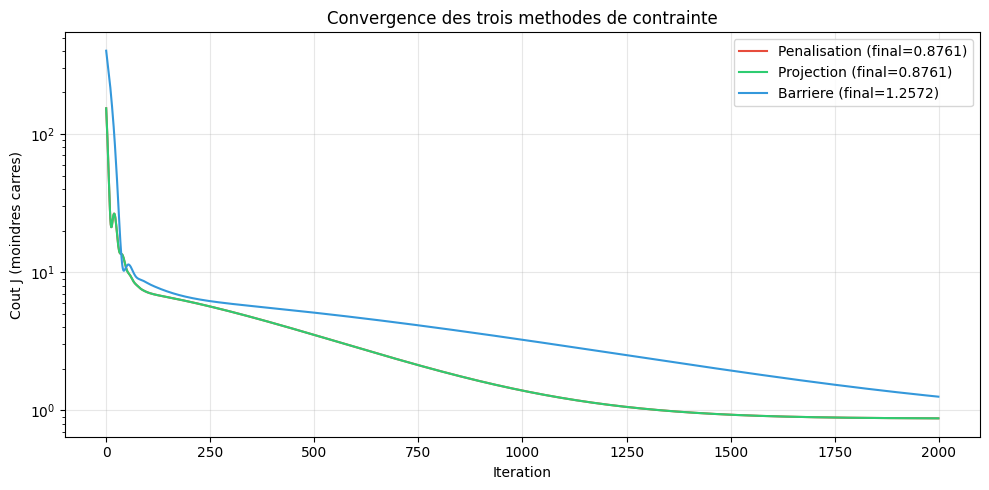

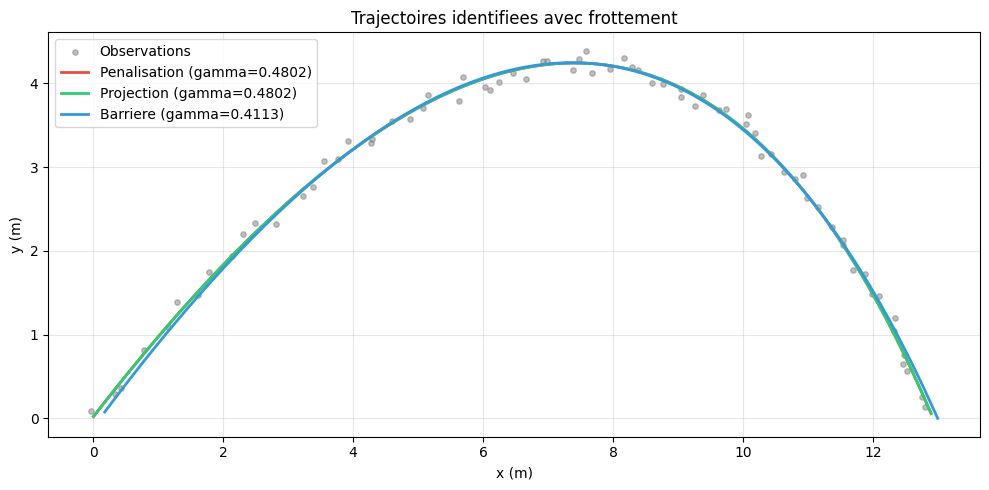

In [9]:
# ---------------------------------------------------------------------------
# Exécution
# ---------------------------------------------------------------------------
# -- Paramètres de simulation -------------------------------------------
CSV_PATH = "observations.csv"
SCRIPT_SIMULATION = "simulation_trajectoire.py"

if not os.path.exists(CSV_PATH):
    print(f"{CSV_PATH} introuvable, lancement de {SCRIPT_SIMULATION}...")
    script_dir = os.path.dirname(os.path.abspath(__file__))
    chemin_script = os.path.join(script_dir, SCRIPT_SIMULATION)
    if not os.path.exists(chemin_script):
        sys.exit(f"Erreur : {SCRIPT_SIMULATION} introuvable dans {script_dir}")
    subprocess.run([sys.executable, chemin_script], check=True)

print("Chargement des observations")
t_np, x_obs_np, y_obs_np = charger_csv(CSV_PATH)

t_tensor = torch.tensor(t_np, dtype=torch.float64)
x_obs = torch.tensor(x_obs_np, dtype=torch.float64)
y_obs = torch.tensor(y_obs_np, dtype=torch.float64)

N_ITER = 2000
LR = 0.01

# -- Methode 1 : Pénalisation -------------------------------------------
print("\n[1/3] Optimisation par penalisation...")
res_pen = optimiser_penalisation(t_tensor, x_obs, y_obs,
                                 n_iter=N_ITER, lr=LR)

# -- Methode 2 : Projection ---------------------------------------------
print("[2/3] Optimisation par projection...")
res_proj = optimiser_projection(t_tensor, x_obs, y_obs,
                                n_iter=N_ITER, lr=LR)

# -- Methode 3 : Barrière -----------------------------------------------
print("[3/3] Optimisation par barriere logarithmique...")
res_bar = optimiser_barriere(t_tensor, x_obs, y_obs,
                             n_iter=N_ITER, lr=LR)

resultats = [res_pen, res_proj, res_bar]

# -- Affichage des resultats --------------------------------------------
print("\n" + "=" * 65)
print(f"{'Methode':<16} {'v0':>8} {'theta':>8} {'gamma':>8} {'Cout':>12}")
print("-" * 65)
for r in resultats:
    print(f"{r['nom']:<16} {r['v0']:>8.3f} {r['theta_deg']:>8.3f} "
          f"{r['gamma']:>8.5f} {r['cout_final']:>12.4e}")
print("=" * 65)

# -- Graphiques ---------------------------------------------------------
tracer_convergence(resultats)
tracer_trajectoires(t_np, x_obs_np, y_obs_np, resultats)

# 5. Analyse de sensibilité et régularisation de Tikhonov

Étude de la variance des paramètres estimés $(v_0, \theta, \gamma)$ en fonction du niveau de bruit $\sigma$.

Comparaison :
- **Sans régularisation** : optimisation brute.
- **Avec régularisation de Tikhonov** : $J_{tikh} = J + \alpha \|\mathbf{p} - \mathbf{p}_{ref}\|^2$

> ATTENTION, WARNING, ACHTUNG : Ce script lance un grand nombre d'optimisations (parallélisées). L'exécution peut prendre plusieurs minutes.

#### sensibilite.py

In [10]:
#"""
#Analyse de sensibilite et regularisation de Tikhonov.
#Evalue la variance des parametres estimes (v0, theta, gamma) en fonction
#du niveau de bruit, et compare l'optimisation avec et sans regularisation.
#"""
#
#import os
#import sys
#import subprocess
#import multiprocessing
#import concurrent.futures
#
#import numpy as np
#import torch
#import matplotlib.pyplot as plt
#from torchdiffeq import odeint
#
#G = 9.81
#
#
## ---------------------------------------------------------------------------
## Modele ODE (identique a methode_frottements.py)
## ---------------------------------------------------------------------------
#class DynamiqueProjectile(torch.nn.Module):
#    def __init__(self, gamma):
#        super().__init__()
#        self.gamma = gamma
#
#    def forward(self, t, state):
#        vx, vy = state[2], state[3]
#        return torch.stack([vx, vy, -self.gamma * vx, -G - self.gamma * vy])
#
#
#def integrer(params, t_tensor):
#    v0, theta = params['v0'], params['theta']
#    x0, y0 = params['x0'], params['y0']
#    gamma = params['gamma']
#
#    vx0 = v0 * torch.cos(theta)
#    vy0 = v0 * torch.sin(theta)
#    etat = torch.stack([x0, y0, vx0, vy0])
#
#    sol = odeint(DynamiqueProjectile(gamma), etat, t_tensor, method='rk4')
#    return sol[:, 0], sol[:, 1]
#
#
## ---------------------------------------------------------------------------
## Fonctions de cout
## ---------------------------------------------------------------------------
#def cout_brut(params, t_tensor, x_obs, y_obs):
#    x_p, y_p = integrer(params, t_tensor)
#    return torch.sum((x_obs - x_p)**2 + (y_obs - y_p)**2)
#
#
#def cout_tikhonov(params, t_tensor, x_obs, y_obs, alpha, p_ref):
#    """Cout moindres carres + regularisation de Tikhonov (Ridge)."""
#    J = cout_brut(params, t_tensor, x_obs, y_obs)
#    reg = alpha * (
#        (params['v0'] - p_ref['v0'])**2 +
#        (params['theta'] - p_ref['theta'])**2 +
#        (params['gamma'] - p_ref['gamma'])**2
#    )
#    return J + reg
#
#
## ---------------------------------------------------------------------------
## Optimisation (projection pour gamma >= 0)
## ---------------------------------------------------------------------------
#def _creer_params(v0_init=12.0, theta_init=0.75, gamma_init=0.2):
#    return {
#        'v0': torch.tensor(v0_init, dtype=torch.float64, requires_grad=True),
#        'theta': torch.tensor(theta_init, dtype=torch.float64, requires_grad=True),
#        'x0': torch.tensor(0.0, dtype=torch.float64, requires_grad=True),
#        'y0': torch.tensor(0.0, dtype=torch.float64, requires_grad=True),
#        'gamma': torch.tensor(gamma_init, dtype=torch.float64, requires_grad=True),
#    }
#
#
#def optimiser(t_tensor, x_obs, y_obs, n_iter=1500, lr=0.01,
#              alpha=0.0, p_ref=None):
#    """
#    Optimise les parametres par descente de gradient projetee.
#    Si alpha > 0, applique la regularisation de Tikhonov.
#    """
#    params = _creer_params()
#    optimizer = torch.optim.Adam(params.values(), lr=lr)
#
#    if p_ref is None:
#        p_ref = {'v0': torch.tensor(12.0, dtype=torch.float64),
#                 'theta': torch.tensor(0.75, dtype=torch.float64),
#                 'gamma': torch.tensor(0.2, dtype=torch.float64)}
#
#    for _ in range(n_iter):
#        optimizer.zero_grad()
#        if alpha > 0:
#            loss = cout_tikhonov(params, t_tensor, x_obs, y_obs, alpha, p_ref)
#        else:
#            loss = cout_brut(params, t_tensor, x_obs, y_obs)
#        loss.backward()
#        optimizer.step()
#        with torch.no_grad():
#            params['gamma'].clamp_(min=0.0)
#
#    return {
#        'v0': params['v0'].item(),
#        'theta_deg': np.degrees(params['theta'].item()),
#        'gamma': params['gamma'].item(),
#    }
#
#
## ---------------------------------------------------------------------------
## Generation de donnees avec frottement (via scipy, pas de dependance torch)
## ---------------------------------------------------------------------------
#def generer_donnees(v0, theta, gamma, sigma, num_points=80):
#    from scipy.integrate import solve_ivp
#
#    def edo(t, s):
#        return [s[2], s[3], -gamma * s[2], -G - gamma * s[3]]
#
#    vx0 = v0 * np.cos(theta)
#    vy0 = v0 * np.sin(theta)
#    t_vol = 2 * v0 * np.sin(theta) / G
#    t_max = t_vol * 1.2
#    t_eval = np.linspace(0, t_max, num_points)
#    sol = solve_ivp(edo, [0, t_max], [0, 0, vx0, vy0],
#                    t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
#
#    t, x, y = sol.t, sol.y[0], sol.y[1]
#    masque = y >= 0
#    t, x, y = t[masque], x[masque], y[masque]
#
#    x_obs = x + np.random.normal(0, sigma, size=x.shape)
#    y_obs = y + np.random.normal(0, sigma, size=y.shape)
#    return t, x_obs, y_obs
#
#
## ---------------------------------------------------------------------------
## Analyse de sensibilite
## ---------------------------------------------------------------------------
#
#def run_single_experiment(args):
#    """
#    Fonction executee par chaque processus du pool.
#    """
#    sigma, v0_vrai, theta_vrai, gamma_vrai, n_iter, lr, alpha_tikhonov = args
#    
#    # 1. Generation des donnees
#    t_np, x_np, y_np = generer_donnees(v0_vrai, theta_vrai, gamma_vrai, sigma)
#    t_t = torch.tensor(t_np, dtype=torch.float64)
#    x_t = torch.tensor(x_np, dtype=torch.float64)
#    y_t = torch.tensor(y_np, dtype=torch.float64)
#
#    p_ref = {
#        'v0': torch.tensor(v0_vrai, dtype=torch.float64),
#        'theta': torch.tensor(theta_vrai, dtype=torch.float64),
#        'gamma': torch.tensor(gamma_vrai, dtype=torch.float64),
#    }
#
#    # 2. Optimisation Brut
#    res_brut = optimiser(t_t, x_t, y_t, n_iter=n_iter, lr=lr, alpha=0.0)
#    
#    # 3. Optimisation Tikhonov
#    res_tikh = optimiser(t_t, x_t, y_t, n_iter=n_iter, lr=lr, 
#                         alpha=alpha_tikhonov, p_ref=p_ref)
#                         
#    return sigma, res_brut, res_tikh
#
#
#def analyse_sensibilite(v0_vrai, theta_vrai, gamma_vrai,
#                        sigmas, n_essais=20, n_iter=1500, lr=0.01,
#                        alpha_tikhonov=5.0):
#    """
#    Analyse de sensibilite parallelisee sur tous les coeurs du CPU.
#    Utilise ProcessPoolExecutor avec le contexte 'spawn' pour un
#    vrai parallelisme multi-processus compatible Jupyter.
#    """
#    resultats = {'brut': {s: [] for s in sigmas},
#                 'tikhonov': {s: [] for s in sigmas}}
#
#    # Preparation de la liste des taches a distribuer
#    taches = []
#    for sigma in sigmas:
#        for _ in range(n_essais):
#            taches.append((sigma, v0_vrai, theta_vrai, gamma_vrai, 
#                           n_iter, lr, alpha_tikhonov))
#
#    total = len(taches)
#    n_workers = os.cpu_count() or 4
#    print(f"Lancement de {total} taches sur {n_workers} workers (processus)")
#
#    # 'spawn' cree des processus Python neufs (pas de fork dangereux)
#    ctx = multiprocessing.get_context("spawn")
#    with concurrent.futures.ProcessPoolExecutor(
#            max_workers=n_workers, mp_context=ctx) as executor:
#        futures = [executor.submit(run_single_experiment, t) for t in taches]
#        for i, future in enumerate(concurrent.futures.as_completed(futures), 1):
#            sigma, res_brut, res_tikh = future.result()
#            resultats['brut'][sigma].append(res_brut)
#            resultats['tikhonov'][sigma].append(res_tikh)
#            
#            # Affichage de la progression
#            print(f"\r  Progression : {i}/{total} taches terminees", end="", flush=True)
#
#    print("\nTermine !")
#    return resultats
#
#
#def calculer_stats(resultats, sigmas):
#    """Calcule moyenne et ecart-type pour chaque sigma et chaque methode."""
#    stats = {}
#    for methode in ['brut', 'tikhonov']:
#        stats[methode] = {'sigma': [], 'v0_moy': [], 'v0_std': [],
#                          'theta_moy': [], 'theta_std': [],
#                          'gamma_moy': [], 'gamma_std': []}
#        for s in sigmas:
#            vals = resultats[methode][s]
#            v0s = [r['v0'] for r in vals]
#            thetas = [r['theta_deg'] for r in vals]
#            gammas = [r['gamma'] for r in vals]
#
#            stats[methode]['sigma'].append(s)
#            stats[methode]['v0_moy'].append(np.mean(v0s))
#            stats[methode]['v0_std'].append(np.std(v0s))
#            stats[methode]['theta_moy'].append(np.mean(thetas))
#            stats[methode]['theta_std'].append(np.std(thetas))
#            stats[methode]['gamma_moy'].append(np.mean(gammas))
#            stats[methode]['gamma_std'].append(np.std(gammas))
#    return stats
#
#
## ---------------------------------------------------------------------------
## Visualisation
## ---------------------------------------------------------------------------
#def tracer_sensibilite(stats, v0_vrai, theta_vrai_deg, gamma_vrai):
#    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#    params_info = [
#        ('v0', 'v0 (m/s)', v0_vrai),
#        ('theta', 'theta (deg)', theta_vrai_deg),
#        ('gamma', 'gamma (s^-1)', gamma_vrai),
#    ]
#
#    for ax, (key, label, vrai) in zip(axes, params_info):
#        for methode, couleur, style in [('brut', '#e74c3c', 'o-'),
#                                         ('tikhonov', '#2ecc71', 's--')]:
#            s = stats[methode]
#            moy = np.array(s[f'{key}_moy'])
#            std = np.array(s[f'{key}_std'])
#            sigma = np.array(s['sigma'])
#
#            ax.errorbar(sigma, moy, yerr=std, fmt=style, color=couleur,
#                        capsize=4, linewidth=1.5, markersize=5,
#                        label=f'{methode.capitalize()}')
#
#        ax.axhline(vrai, color='gray', linestyle=':', linewidth=1,
#                   label=f'Vrai ({vrai})')
#        ax.set_xlabel('Sigma bruit (m)')
#        ax.set_ylabel(label)
#        ax.set_title(f'Sensibilite de {label}')
#        ax.legend(fontsize=8)
#        ax.grid(True, alpha=0.3)
#
#    plt.suptitle('Sensibilite et regularisation de Tikhonov',
#                 fontsize=13, fontweight='bold')
#    plt.tight_layout()
#    plt.savefig('sensibilite.png', dpi=150)
#    plt.show()
#
#
#def tracer_variance(stats):
#    fig, ax = plt.subplots(figsize=(10, 5))
#
#    for methode, couleur, style in [('brut', '#e74c3c', 'o-'),
#                                     ('tikhonov', '#2ecc71', 's--')]:
#        s = stats[methode]
#        sigma = np.array(s['sigma'])
#        var_totale = (np.array(s['v0_std'])**2 +
#                      np.array(s['theta_std'])**2 +
#                      np.array(s['gamma_std'])**2)
#        ax.plot(sigma, var_totale, style, color=couleur, linewidth=1.5,
#                markersize=5, label=f'{methode.capitalize()}')
#
#    ax.set_xlabel('Sigma bruit (m)')
#    ax.set_ylabel('Variance totale cumulee')
#    ax.set_title('Variance totale vs niveau de bruit')
#    ax.legend()
#    ax.grid(True, alpha=0.3)
#    ax.set_yscale('log')
#
#    plt.tight_layout()
#    plt.savefig('variance.png', dpi=150)
#    plt.show()
#
#
## ---------------------------------------------------------------------------
## Point d'entree
## ---------------------------------------------------------------------------
#if __name__ == '__main__':
#
#    V0_VRAI = 15.0
#    THETA_VRAI = np.pi / 4
#    GAMMA_VRAI = 0.5
#
#    SIGMAS = [0.01, 0.03, 0.05, 0.08, 0.12, 0.20]
#    N_ESSAIS = 15
#    N_ITER = 1500
#    LR = 0.01
#    ALPHA_TIKHONOV = 5.0
#
#    print(f"Parametres vrais : v0={V0_VRAI}, theta={np.degrees(THETA_VRAI):.1f} deg, "
#          f"gamma={GAMMA_VRAI}")
#    print(f"Niveaux de bruit : {SIGMAS}")
#    print(f"Essais par sigma : {N_ESSAIS}")
#    print(f"Alpha Tikhonov : {ALPHA_TIKHONOV}")
#    print(f"Total optimisations : {len(SIGMAS) * N_ESSAIS * 2}\n")
#
#    resultats = analyse_sensibilite(
#        V0_VRAI, THETA_VRAI, GAMMA_VRAI,
#        SIGMAS, n_essais=N_ESSAIS, n_iter=N_ITER, lr=LR,
#        alpha_tikhonov=ALPHA_TIKHONOV
#    )
#
#    stats = calculer_stats(resultats, SIGMAS)
#
#    # -- Tableau recapitulatif ----------------------------------------------
#    print(f"\n{'sigma':>6} | {'--- Sans regul ---':^30} | {'--- Tikhonov ---':^30}")
#    print(f"{'':>6} | {'v0':>8} {'theta':>8} {'gamma':>8}  | {'v0':>8} {'theta':>8} {'gamma':>8}")
#    print("-" * 75)
#    for i, s in enumerate(SIGMAS):
#        sb = stats['brut']
#        st = stats['tikhonov']
#        print(f"{s:>6.3f} | "
#              f"{sb['v0_moy'][i]:>6.2f}+/-{sb['v0_std'][i]:<5.3f} "
#              f"{sb['theta_moy'][i]:>6.2f}+/-{sb['theta_std'][i]:<5.3f} "
#              f"{sb['gamma_moy'][i]:>6.3f}+/-{sb['gamma_std'][i]:<5.4f} | "
#              f"{st['v0_moy'][i]:>6.2f}+/-{st['v0_std'][i]:<5.3f} "
#              f"{st['theta_moy'][i]:>6.2f}+/-{st['theta_std'][i]:<5.3f} "
#              f"{st['gamma_moy'][i]:>6.3f}+/-{st['gamma_std'][i]:<5.4f}")
#
#    # -- Graphiques ---------------------------------------------------------
#    tracer_sensibilite(stats, V0_VRAI, np.degrees(THETA_VRAI), GAMMA_VRAI)
#    tracer_variance(stats)
#

#### Exécution — sensibilite.py

Parametres vrais : v0=15.0, theta=45.0 deg, gamma=0.5
Niveaux de bruit : [0.01, 0.03, 0.05, 0.08, 0.12, 0.2]
Essais par sigma : 15
Alpha Tikhonov : 5.0
Total optimisations : 180

Lancement de 90 taches sur 16 workers (processus)
  Progression : 90/90 taches terminees
Termine !

 sigma |       --- Sans regul ---       |        --- Tikhonov ---       
       |       v0    theta    gamma  |       v0    theta    gamma
---------------------------------------------------------------------------
 0.010 |  14.71+/-0.011  45.43+/-0.018  0.469+/-0.0011 |  15.00+/-0.001  45.00+/-0.019  0.500+/-0.0003
 0.030 |  14.71+/-0.024  45.42+/-0.065  0.469+/-0.0030 |  15.00+/-0.003  45.00+/-0.047  0.500+/-0.0012
 0.050 |  14.70+/-0.046  45.44+/-0.111  0.469+/-0.0045 |  15.00+/-0.006  45.00+/-0.078  0.500+/-0.0020
 0.080 |  14.71+/-0.069  45.41+/-0.185  0.470+/-0.0094 |  15.00+/-0.009  44.98+/-0.131  0.500+/-0.0037
 0.120 |  14.75+/-0.108  45.40+/-0.332  0.473+/-0.0132 |  15.01+/-0.014  45.03+/-0.224  0.500+

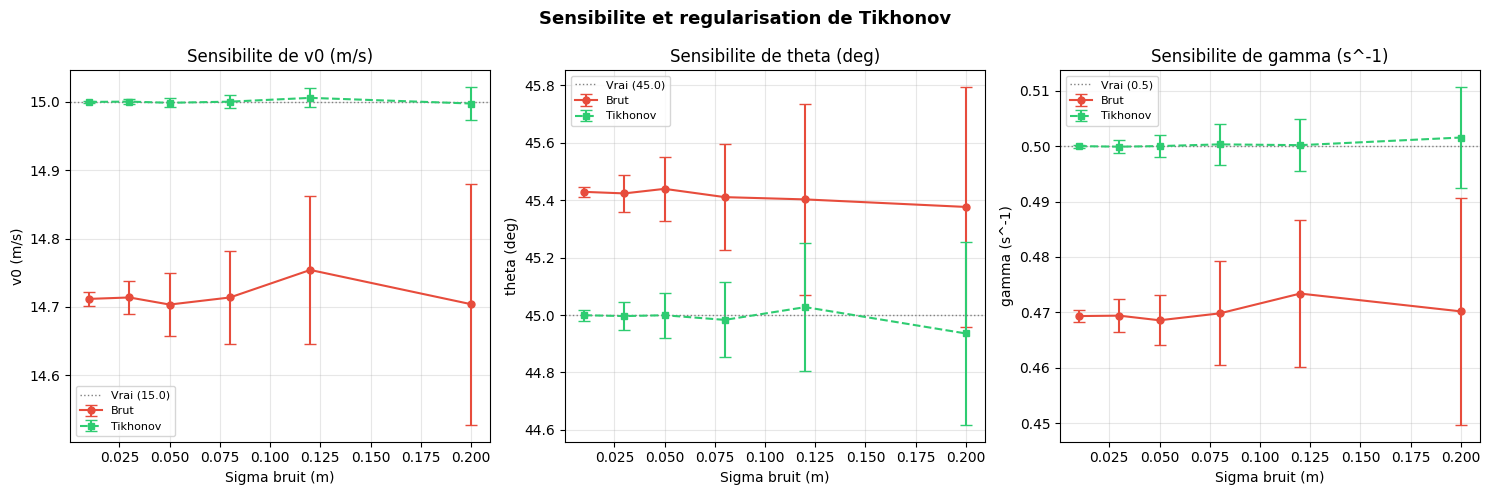

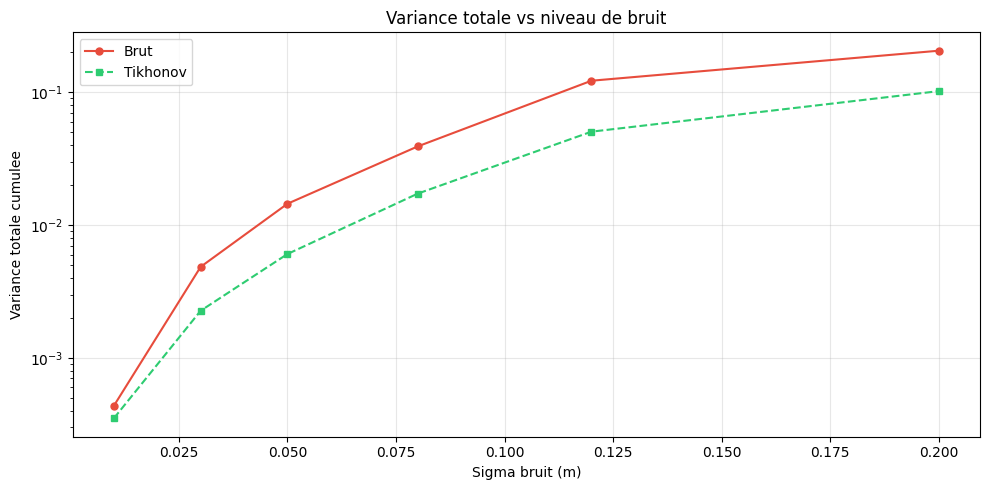

In [11]:
# ---------------------------------------------------------------------------
# Exécution
# ---------------------------------------------------------------------------
# -- Paramètres de simulation -------------------------------------------
V0_VRAI = 15.0
THETA_VRAI = np.pi / 4
GAMMA_VRAI = 0.5

SIGMAS = [0.01, 0.03, 0.05, 0.08, 0.12, 0.20]
N_ESSAIS = 15
N_ITER = 1500
LR = 0.01
ALPHA_TIKHONOV = 5.0

print(f"Parametres vrais : v0={V0_VRAI}, theta={np.degrees(THETA_VRAI):.1f} deg, "
      f"gamma={GAMMA_VRAI}")
print(f"Niveaux de bruit : {SIGMAS}")
print(f"Essais par sigma : {N_ESSAIS}")
print(f"Alpha Tikhonov : {ALPHA_TIKHONOV}")
print(f"Total optimisations : {len(SIGMAS) * N_ESSAIS * 2}\n")

resultats = analyse_sensibilite(
    V0_VRAI, THETA_VRAI, GAMMA_VRAI,
    SIGMAS, n_essais=N_ESSAIS, n_iter=N_ITER, lr=LR,
    alpha_tikhonov=ALPHA_TIKHONOV
)

stats = calculer_stats(resultats, SIGMAS)

# -- Tableau recapitulatif ----------------------------------------------
print(f"\n{'sigma':>6} | {'--- Sans regul ---':^30} | {'--- Tikhonov ---':^30}")
print(f"{'':>6} | {'v0':>8} {'theta':>8} {'gamma':>8}  | {'v0':>8} {'theta':>8} {'gamma':>8}")
print("-" * 75)
for i, s in enumerate(SIGMAS):
    sb = stats['brut']
    st = stats['tikhonov']
    print(f"{s:>6.3f} | "
          f"{sb['v0_moy'][i]:>6.2f}+/-{sb['v0_std'][i]:<5.3f} "
          f"{sb['theta_moy'][i]:>6.2f}+/-{sb['theta_std'][i]:<5.3f} "
          f"{sb['gamma_moy'][i]:>6.3f}+/-{sb['gamma_std'][i]:<5.4f} | "
          f"{st['v0_moy'][i]:>6.2f}+/-{st['v0_std'][i]:<5.3f} "
          f"{st['theta_moy'][i]:>6.2f}+/-{st['theta_std'][i]:<5.3f} "
          f"{st['gamma_moy'][i]:>6.3f}+/-{st['gamma_std'][i]:<5.4f}")

# -- Graphiques ---------------------------------------------------------
tracer_sensibilite(stats, V0_VRAI, np.degrees(THETA_VRAI), GAMMA_VRAI)
tracer_variance(stats)

# 6. Simulation avec traînée quadratique

Extension au modèle de traînée quadratique :

$$\mathbf{F}_{drag} = -c \, |\mathbf{v}| \, \mathbf{v} \qquad \Rightarrow \qquad \gamma_q = c/m$$

Génère des observations bruitées au format CSV commun.

#### simulation_trajectoire_quad.py

In [12]:
"""
Simulation d'une trajectoire balistique avec trainée quadratique.
Force : F_drag = -c * |v| * v  =>  gamma_q = c/m
Génère des observations bruitees au format CSV commun (t,x,y).
"""


def generate_trajectory_drag_quad(v0, theta, gamma_q, t_max, num_points):
    """
    Calcule la trajectoire avec trainee quadratique.
    EDO : dvx/dt = -gamma_q * |v| * vx
          dvy/dt = -g - gamma_q * |v| * vy
    Integration par RK45.

    Parameters
    ----------
    v0 : float
        Vitesse initiale (m/s).
    theta : float
        Angle de tir (rad).
    gamma_q : float
        Coefficient de trainee quadratique c/m (m^-1).
    t_max : float
        Duree maximale (s).
    num_points : int
        Nombre de points temporels.

    Returns
    -------
    t, x, y : np.ndarray
    """
    def edo(t, state):
        _, _, vx, vy = state
        v_norm = np.sqrt(vx**2 + vy**2)
        return [vx, vy, -gamma_q * v_norm * vx, -G - gamma_q * v_norm * vy]

    vx0 = v0 * np.cos(theta)
    vy0 = v0 * np.sin(theta)
    etat0 = [0.0, 0.0, vx0, vy0]

    t_eval = np.linspace(0, t_max, num_points)
    sol = solve_ivp(edo, [0, t_max], etat0, t_eval=t_eval, method='RK45',
                    rtol=1e-10, atol=1e-12)

    return sol.t, sol.y[0], sol.y[1]


def ajouter_bruit(x, y, sigma=0.05):
    """Ajoute un bruit blanc gaussien aux coordonnées."""
    bruit_x = np.random.normal(0, sigma, size=x.shape)
    bruit_y = np.random.normal(0, sigma, size=y.shape)
    return x + bruit_x, y + bruit_y


def tracer_trajectoire(t, x_th, y_th, x_obs, y_obs, v0, theta_deg, gamma_q):
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(x_th, y_th, 'b-', linewidth=2, label='Trajectoire theorique')
    ax.scatter(x_obs, y_obs, c='r', s=20, alpha=0.7, zorder=5,
               label='Observations bruitees')

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(f'Trainee quadratique  |  v0={v0} m/s, '
                 f'theta={theta_deg:.1f} deg, gamma_q={gamma_q}')
    ax.legend()
    ax.set_ylim(bottom=-0.5)
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('trajectoire_quad_simulee.png', dpi=150)
    plt.show()

#### Exécution — simulation_trajectoire_quad.py

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Mode : trainee quadratique (gamma_q=0.05)
Parametres : v0=40.0 m/s, theta=45.0 deg, gamma_q=0.05
Points generes : 46
Bruit (sigma) : 0.08 m

Apercu des donnees (t, x_obs, y_obs) :
  t=0.0000 s  |  x=0.0788 m  |  y=0.0053 m
  t=0.0699 s  |  x=1.8586 m  |  y=1.6600 m
  t=0.1398 s  |  x=3.5453 m  |  y=3.3073 m
  t=0.2097 s  |  x=5.0202 m  |  y=4.7837 m
  t=0.2796 s  |  x=6.2761 m  |  y=6.1092 m
  t=0.3495 s  |  x=7.5157 m  |  y=6.9858 m
  t=0.4194 s  |  x=8.6534 m  |  y=7.9014 m
  t=0.4893 s  |  x=9.7795 m  |  y=8.8224 m
  ... (38 points supplementaires)
Donnees bruitees sauvegardees dans observations_quad.csv
Trajectoire theorique sauvegardee dans trajectoire_theorique_quad.csv


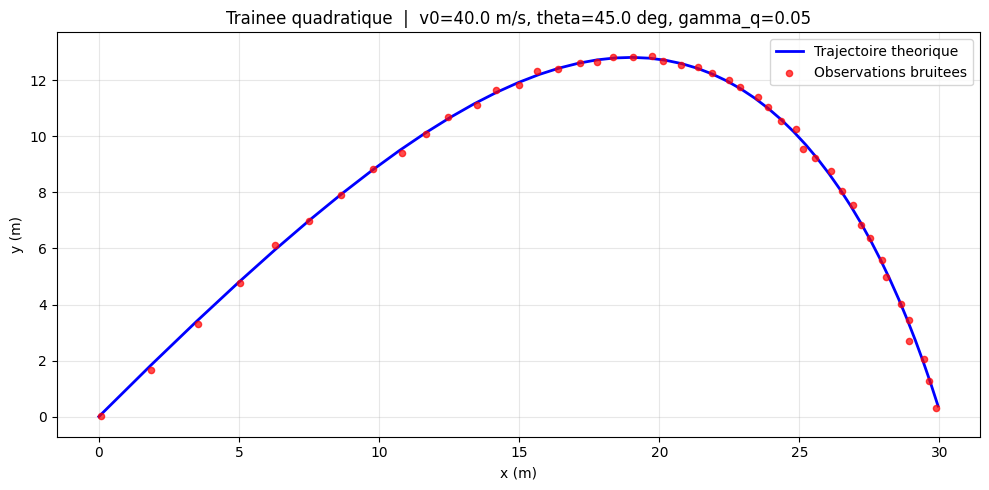

In [13]:
# ---------------------------------------------------------------------------
# Exécution
# ---------------------------------------------------------------------------
# -- Paramètres de simulation -------------------------------------------
v0 = 40.0
theta = np.pi / 4
theta_deg = np.degrees(theta)
num_points = 100
sigma_bruit = 0.08

GAMMA_Q = 0.05

# -- Generation ---------------------------------------------------------
t_vol = 2 * v0 * np.sin(theta) / G
t_max = t_vol * 1.2
t, x_th, y_th = generate_trajectory_drag_quad(v0, theta, GAMMA_Q,
                                               t_max, num_points)
print(f"Mode : trainee quadratique (gamma_q={GAMMA_Q})")

x_obs, y_obs = ajouter_bruit(x_th, y_th, sigma=sigma_bruit)

# Tronquer les points sous le sol
masque = y_th >= 0
t = t[masque]
x_th = x_th[masque]
y_th = y_th[masque]
x_obs = x_obs[masque]
y_obs = y_obs[masque]

# -- Affichage ----------------------------------------------------------
print(f"Parametres : v0={v0} m/s, theta={theta_deg:.1f} deg, gamma_q={GAMMA_Q}")
print(f"Points generes : {len(t)}")
print(f"Bruit (sigma) : {sigma_bruit} m\n")

print("Apercu des donnees (t, x_obs, y_obs) :")
for i in range(min(8, len(t))):
    print(f"  t={t[i]:.4f} s  |  x={x_obs[i]:.4f} m  |  y={y_obs[i]:.4f} m")
if len(t) > 8:
    print(f"  ... ({len(t) - 8} points supplementaires)")

# -- Sauvegarde CSV -----------------------------------------------------
with open("observations_quad.csv", "w") as f:
    f.write("t,x,y\n")
    for i in range(len(t)):
        f.write(f"{t[i]:.6f},{x_obs[i]:.6f},{y_obs[i]:.6f}\n")
print("Donnees bruitees sauvegardees dans observations_quad.csv")

with open("trajectoire_theorique_quad.csv", "w") as f:
    f.write("t,x,y\n")
    for i in range(len(t)):
        f.write(f"{t[i]:.6f},{x_th[i]:.6f},{y_th[i]:.6f}\n")
print("Trajectoire theorique sauvegardee dans trajectoire_theorique_quad.csv")

tracer_trajectoire(t, x_th, y_th, x_obs, y_obs, v0, theta_deg, GAMMA_Q)

# 7. Comparaison traînée linéaire vs quadratique

Reconstruction de la trajectoire avec les deux modèles de traînée et comparaison numérique/visuelle des résultats.

#### methode_drag_quad.py

In [14]:
"""
Extension - Modèle balistique avec trainée quadratique.
Force de trainée proportionnelle au carré de la vitesse :
    F_drag = -c * |v| * v   =>  paramètre gamma_q = c/m
Compare la reconstruction avec le modéle lineéire et le modèle quadratique.
"""


# ===========================================================================
# EDO : modele lineaire (rappel)
# ===========================================================================
class DragLineaire(torch.nn.Module):
    """dvx/dt = -gamma*vx, dvy/dt = -g - gamma*vy"""
    def __init__(self, gamma):
        super().__init__()
        self.gamma = gamma

    def forward(self, t, state):
        vx, vy = state[2], state[3]
        return torch.stack([vx, vy,
                            -self.gamma * vx,
                            -G - self.gamma * vy])


# ===========================================================================
# EDO : modele quadratique
# ===========================================================================
class DragQuadratique(torch.nn.Module):
    """
    dvx/dt = -gamma_q * |v| * vx
    dvy/dt = -g - gamma_q * |v| * vy
    ou |v| = sqrt(vx^2 + vy^2)
    """
    def __init__(self, gamma_q):
        super().__init__()
        self.gamma_q = gamma_q

    def forward(self, t, state):
        vx, vy = state[2], state[3]
        vitesse = torch.sqrt(vx**2 + vy**2 + 1e-12)
        return torch.stack([vx, vy,
                            -self.gamma_q * vitesse * vx,
                            -G - self.gamma_q * vitesse * vy])


# ===========================================================================
# Integration generique
# ===========================================================================
def integrer(params, t_tensor, modele_class):
    v0 = params['v0']
    theta = params['theta']
    x0 = params['x0']
    y0 = params['y0']
    gamma = params['gamma']

    vx0 = v0 * torch.cos(theta)
    vy0 = v0 * torch.sin(theta)
    etat = torch.stack([x0, y0, vx0, vy0])

    dynamique = modele_class(gamma)
    sol = odeint(dynamique, etat, t_tensor, method='rk4')
    return sol[:, 0], sol[:, 1]


def cout(params, t_tensor, x_obs, y_obs, modele_class):
    x_p, y_p = integrer(params, t_tensor, modele_class)
    return torch.sum((x_obs - x_p)**2 + (y_obs - y_p)**2)


# ===========================================================================
# Optimisation (projection)
# ===========================================================================
def _creer_params(v0_init=35.0, theta_init=0.75, gamma_init=0.2):
    return {
        'v0': torch.tensor(v0_init, dtype=torch.float64, requires_grad=True),
        'theta': torch.tensor(theta_init, dtype=torch.float64, requires_grad=True),
        'x0': torch.tensor(0.0, dtype=torch.float64, requires_grad=True),
        'y0': torch.tensor(0.0, dtype=torch.float64, requires_grad=True),
        'gamma': torch.tensor(gamma_init, dtype=torch.float64, requires_grad=True),
    }


def optimiser(t_tensor, x_obs, y_obs, modele_class, nom,
              n_iter=2000, lr=0.01):
    params = _creer_params()
    optimizer = torch.optim.Adam(params.values(), lr=lr)
    historique = []

    for _ in range(n_iter):
        optimizer.zero_grad()
        J = cout(params, t_tensor, x_obs, y_obs, modele_class)
        J.backward()
        optimizer.step()
        with torch.no_grad():
            params['gamma'].clamp_(min=0.0)
        historique.append(J.item())

    return {
        'nom': nom,
        'v0': params['v0'].item(),
        'theta_rad': params['theta'].item(),
        'theta_deg': np.degrees(params['theta'].item()),
        'x0': params['x0'].item(),
        'y0': params['y0'].item(),
        'gamma': params['gamma'].item(),
        'cout_final': historique[-1],
        'historique': historique,
        'modele_class': modele_class,
    }


# ===========================================================================
# Chargement CSV
# ===========================================================================
def charger_csv(chemin):
    data = np.loadtxt(chemin, delimiter=",", skiprows=1)
    return data[:, 0], data[:, 1], data[:, 2]


# ===========================================================================
# Visualisation
# ===========================================================================
def tracer_comparaison(t_np, x_obs_np, y_obs_np, res_lin, res_quad):
    """Superpose les trajectoires reconstruites par les deux modeles."""
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.scatter(x_obs_np, y_obs_np, c='gray', s=15, alpha=0.5,
               label='Observations', zorder=1)

    t_dense = torch.linspace(0, float(t_np[-1]), 300, dtype=torch.float64)

    for res, couleur, style in [(res_lin, '#e74c3c', '-'),
                                 (res_quad, '#2ecc71', '--')]:
        params = {
            'v0': torch.tensor(res['v0'], dtype=torch.float64),
            'theta': torch.tensor(res['theta_rad'], dtype=torch.float64),
            'x0': torch.tensor(res['x0'], dtype=torch.float64),
            'y0': torch.tensor(res['y0'], dtype=torch.float64),
            'gamma': torch.tensor(res['gamma'], dtype=torch.float64),
        }
        with torch.no_grad():
            x_fit, y_fit = integrer(params, t_dense, res['modele_class'])
        ax.plot(x_fit.numpy(), y_fit.numpy(), color=couleur, linewidth=2,
                linestyle=style, zorder=2,
                label=f'{res["nom"]} (gamma={res["gamma"]:.4f})')

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title('Comparaison : trainee lineaire vs quadratique')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('drag_comparaison.png', dpi=150)
    plt.show()


def tracer_convergence(res_lin, res_quad):
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(res_lin['historique'], color='#e74c3c', linewidth=1.5,
            label=f'Lineaire (final={res_lin["cout_final"]:.4f})')
    ax.plot(res_quad['historique'], color='#2ecc71', linewidth=1.5,
            label=f'Quadratique (final={res_quad["cout_final"]:.4f})')

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Cout J')
    ax.set_title('Convergence : lineaire vs quadratique')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('drag_convergence.png', dpi=150)
    plt.show()

#### Exécution — methode_drag_quad.py

Chargement des observations

[1/2] Reconstruction par modele lineaire...
[2/2] Reconstruction par modele quadratique...

Modele               v0    theta    gamma         Cout
----------------------------------------------------------------------
Lineaire         33.716   41.319  0.77920   3.3866e+01
Quadratique      36.118   45.962  0.04624   1.9861e+00


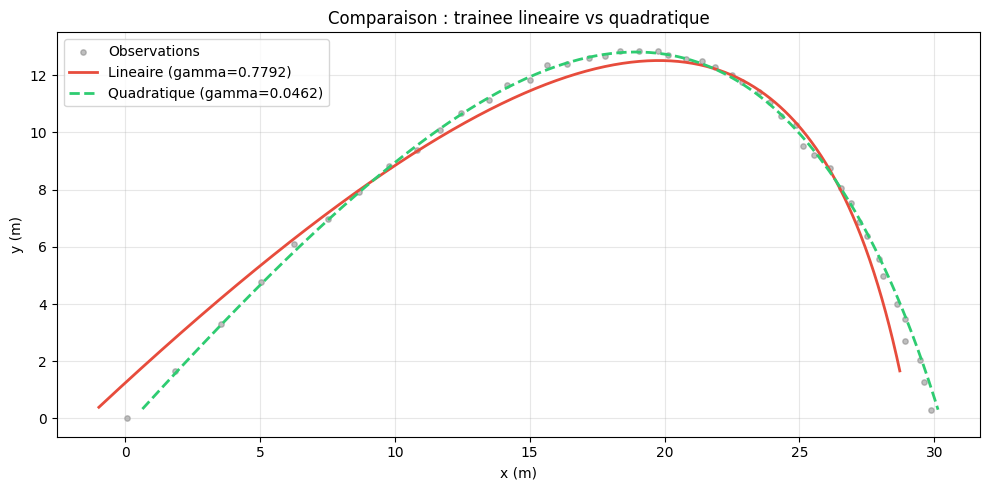

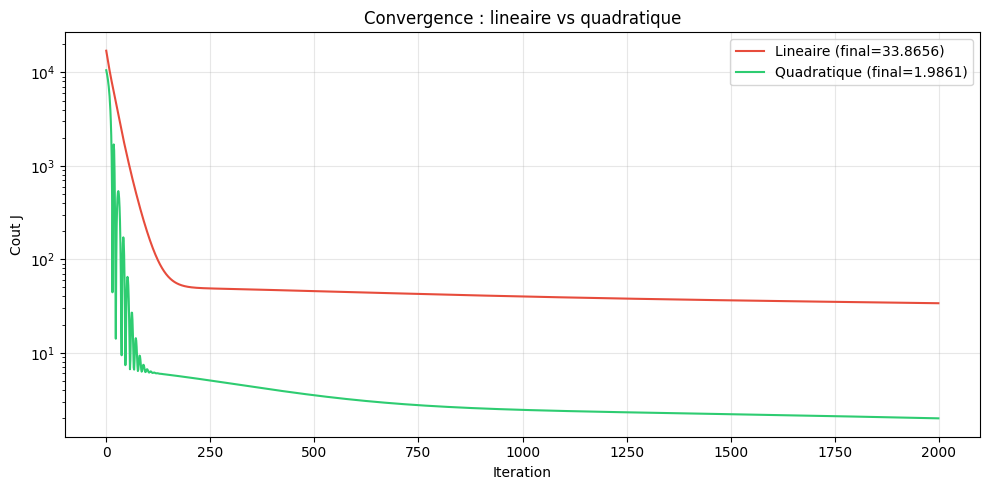

In [15]:
# ---------------------------------------------------------------------------
# Exécution
# ---------------------------------------------------------------------------
# -- Paramètres de simulation -------------------------------------------
CSV_PATH = "observations_quad.csv"
SCRIPT_SIMULATION = "simulation_trajectoire_quad.py"
N_ITER = 2000
LR = 0.01

if not os.path.exists(CSV_PATH):
    print(f"{CSV_PATH} introuvable, lancement de {SCRIPT_SIMULATION}...")
    script_dir = os.path.dirname(os.path.abspath(__file__))
    chemin_script = os.path.join(script_dir, SCRIPT_SIMULATION)
    if not os.path.exists(chemin_script):
        sys.exit(f"Erreur : {SCRIPT_SIMULATION} introuvable dans {script_dir}")
    subprocess.run([sys.executable, chemin_script], check=True)

print("Chargement des observations")
t_np, x_obs_np, y_obs_np = charger_csv(CSV_PATH)

t_t = torch.tensor(t_np, dtype=torch.float64)
x_t = torch.tensor(x_obs_np, dtype=torch.float64)
y_t = torch.tensor(y_obs_np, dtype=torch.float64)

# -- Reconstruction avec le modèle lineaire -----------------------------
print("\n[1/2] Reconstruction par modele lineaire...")
res_lin = optimiser(t_t, x_t, y_t, DragLineaire, "Lineaire",
                    n_iter=N_ITER, lr=LR)

# -- Reconstruction avec le modèle quadratique --------------------------
print("[2/2] Reconstruction par modele quadratique...")
res_quad = optimiser(t_t, x_t, y_t, DragQuadratique, "Quadratique",
                     n_iter=N_ITER, lr=LR)

# -- Tableau comparatif -------------------------------------------------
print("\n" + "=" * 70)
print(f"{'Modele':<14} {'v0':>8} {'theta':>8} {'gamma':>8} {'Cout':>12}")
print("-" * 70)
for r in [res_lin, res_quad]:
    print(f"{r['nom']:<14} {r['v0']:>8.3f} {r['theta_deg']:>8.3f} "
          f"{r['gamma']:>8.5f} {r['cout_final']:>12.4e}")
print("=" * 70)

# -- Graphiques ---------------------------------------------------------
tracer_comparaison(t_np, x_obs_np, y_obs_np, res_lin, res_quad)
tracer_convergence(res_lin, res_quad)